# Per-spike diagnostics: the paper's workflow

This tutorial reproduces, at small scale, the workflow of *Local goodness-of-fit
measures for neural decoding* (Zeng, Comrie, Frank, Eden and Denovellis):

1. decode position from place-cell spikes with a state space model;
2. compute three diagnostics for **every spike**, comparing what the spike says about
   position with the decoder's one-step prediction;
3. set flagging thresholds from a baseline period where the model fits;
4. find when, and for which units, the model fails;
5. check whether a revised model fixes the flagged spikes.

The simulated session has a known misfit: halfway through, a third of the cells
change their place fields ("remap"), but the decoder keeps using the old ones.

It needs only NumPy, matplotlib and `statespacecheck`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import statespacecheck as ssc

rng = np.random.default_rng(42)

## 1. A simulated session

An animal runs back and forth on a 100 cm track for 60 s. Each of 30 place cells
fires at a rate that depends on position. At 30 s, ten cells remap to new locations.

In [2]:
dt = 0.02  # time-bin width (s)
n_time = 3000  # 60 s
position_bins = np.linspace(0, 100, 51)  # cm
n_units = 30
remap_time = n_time // 2


def place_fields_at(centers: np.ndarray) -> np.ndarray:
    """Return the firing rate (Hz) of each unit at each position bin, (n_bins, n_units)."""
    tuning = np.exp(-0.5 * ((position_bins[:, None] - centers) / 6.0) ** 2)
    return 0.2 + 25.0 * tuning


centers_before = rng.uniform(0, 100, n_units)
remapped = rng.choice(n_units, size=10, replace=False)
centers_after = centers_before.copy()
centers_after[remapped] = rng.uniform(0, 100, remapped.size)
fields_before = place_fields_at(centers_before)
fields_after = place_fields_at(centers_after)

# Smooth back-and-forth running
time = np.arange(n_time) * dt
true_position = 50 + 45 * np.sin(2 * np.pi * time / 12)
true_bin = np.abs(position_bins[:, None] - true_position).argmin(axis=0)

# Spikes: Poisson counts from the fields in effect at each time
rates = np.where(
    (np.arange(n_time) < remap_time)[:, None],
    fields_before[true_bin],
    fields_after[true_bin],
)
spike_counts = rng.poisson(rates * dt)  # (n_time, n_units)
print(f"{spike_counts.sum()} spikes from {n_units} units")

7056 spikes from 30 units


## 2. Decoding with a state space model

The decoder is a grid filter. Its state transition model is a Gaussian random walk
over the position bins, and its observation model is Poisson spiking with the
place fields estimated **before** the remapping. At each time bin it forms the
one-step predictive distribution $P_k(x) = p(x_k \mid y_{1:k-1})$, then updates it
with the spikes in that bin. The diagnostics use $P_k$.

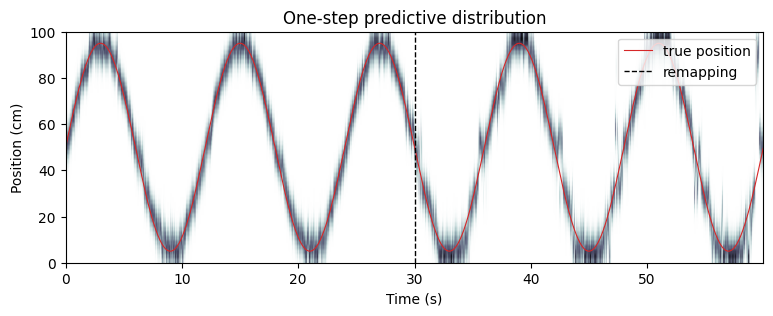

In [3]:
def decode(place_fields: np.ndarray) -> np.ndarray:
    """Return the one-step predictive distribution of a grid filter, (n_time, n_bins)."""
    step = position_bins[:, None] - position_bins[None, :]
    transition = np.exp(-0.5 * (step / 3.0) ** 2)
    transition /= transition.sum(axis=0, keepdims=True)  # column x' -> x

    expected = place_fields * dt  # (n_bins, n_units)
    log_likelihood = spike_counts @ np.log(expected).T - expected.sum(axis=1)

    predictive = np.empty((n_time, position_bins.size))
    posterior = np.full(position_bins.size, 1 / position_bins.size)
    for k in range(n_time):
        predictive[k] = transition @ posterior
        log_posterior = np.log(predictive[k]) + log_likelihood[k]
        posterior = np.exp(log_posterior - log_posterior.max())
        posterior /= posterior.sum()
    return predictive


predictive = decode(fields_before)

fig, ax = plt.subplots(figsize=(9, 3))
ax.imshow(
    predictive.T,
    aspect="auto",
    origin="lower",
    extent=(time[0], time[-1], position_bins[0], position_bins[-1]),
    cmap="bone_r",
)
ax.plot(time, true_position, color="tab:red", linewidth=0.8, label="true position")
ax.axvline(time[remap_time], color="k", linestyle="--", linewidth=1, label="remapping")
ax.set(xlabel="Time (s)", ylabel="Position (cm)", title="One-step predictive distribution")
ax.legend(loc="upper right")
plt.show()

## 3. Diagnostics for every spike

`event_diagnostics` needs the predictive distribution, each unit's firing rate at
each position, and the time bin and unit of each spike. A time bin with several
spikes contributes one event per spike.

In [4]:
time_bin, unit_ind = np.nonzero(spike_counts)
n_spikes = spike_counts[time_bin, unit_ind]
spike_time_ind = np.repeat(time_bin, n_spikes)
spike_unit = np.repeat(unit_ind, n_spikes)

diagnostics = ssc.event_diagnostics(predictive, fields_before, spike_time_ind, spike_unit)
print(diagnostics._fields)

('hpd_overlap', 'kl_divergence', 'predictive_pvalue', 'likelihood')


For each spike:

- **HPD overlap**: how much the 95% highest-density regions of the prediction and of
  the spike's single-event likelihood overlap (0 to 1; low is poor fit);
- **predictive p-value**: the probability, under the prediction, of a spike from a
  unit at most as probable as the one that fired (low is poor fit);
- **KL divergence** from the prediction to the spike's likelihood (high is poor fit,
  but see below).

## 4. Thresholds from a baseline

The thresholds come from a period where the model is believed to fit: here the first
10 s. As in the paper, an HPD overlap at or below the baseline's 1st percentile, or a
KL divergence at or above its 99th percentile, is flagged, and so is any p-value at or
below 0.05.

In [5]:
spike_time = time[spike_time_ind]
baseline = spike_time < 10.0
thresholds = {
    "hpd_overlap_threshold": ssc.baseline_threshold(diagnostics.hpd_overlap[baseline], 0.01),
    "kl_divergence_threshold": ssc.baseline_threshold(
        diagnostics.kl_divergence[baseline], 0.99
    ),
}
print({name: round(value, 3) for name, value in thresholds.items()})
flags = ssc.flag_events(diagnostics, **thresholds, pvalue_threshold=0.05)

after = spike_time >= time[remap_time]
print(f"{'diagnostic':20s} before remapping   after remapping")
for name in flags._fields:
    flagged = getattr(flags, name)
    print(f"{name:20s} {flagged[~after].mean():>15.1%} {flagged[after].mean():>17.1%}")

{'hpd_overlap_threshold': 0.0, 'kl_divergence_threshold': 4.784}
diagnostic           before remapping   after remapping
hpd_overlap                     2.9%             22.3%
kl_divergence                   1.1%              4.9%
predictive_pvalue               3.6%             23.9%


The HPD-overlap threshold is 0: more than 1% of baseline spikes already have no
overlap, so only spikes with no overlap at all are flagged ("at or below" the
threshold). Before the remapping each diagnostic flags a few percent of spikes;
after it, many more.

Plotted per spike, as in the paper's figures, with the p-value shown as $-\log p$ so
that poor fit points up:

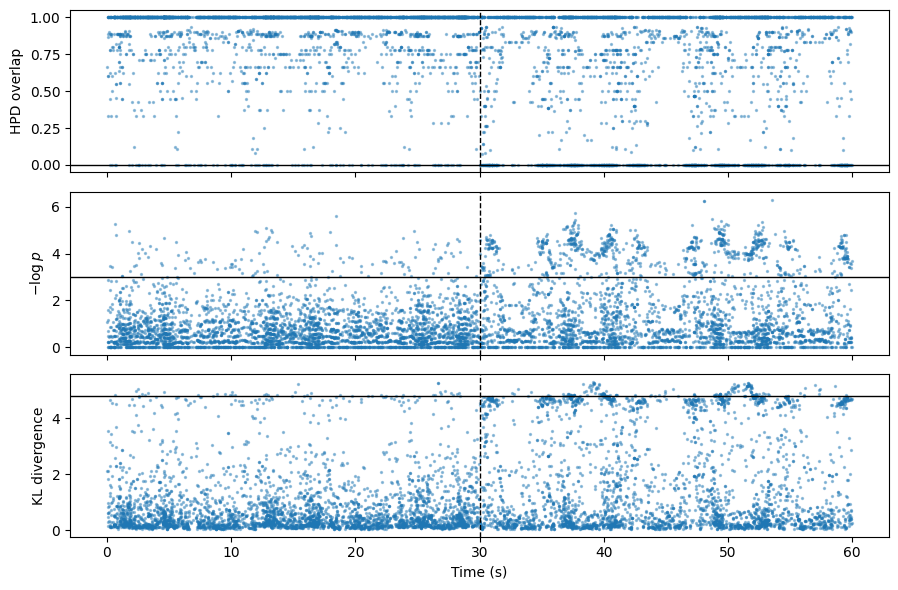

In [6]:
panels = [
    ("HPD overlap", diagnostics.hpd_overlap, thresholds["hpd_overlap_threshold"]),
    ("$-\\log p$", -np.log(diagnostics.predictive_pvalue), -np.log(0.05)),
    ("KL divergence", diagnostics.kl_divergence, thresholds["kl_divergence_threshold"]),
]
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 6))
for ax, (label, values, threshold) in zip(axes, panels, strict=True):
    ax.scatter(spike_time, values, s=2, alpha=0.4)
    ax.axhline(threshold, color="k", linewidth=1)
    ax.axvline(time[remap_time], color="k", linestyle="--", linewidth=1)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

## 5. Which units are responsible?

Flags can be broken down by unit. Most of the units that remapped are among the most
often flagged, pointing to the observation model (their place fields) rather than to
the state transition model.

8 of the 10 most-flagged units after remapping are ones that remapped


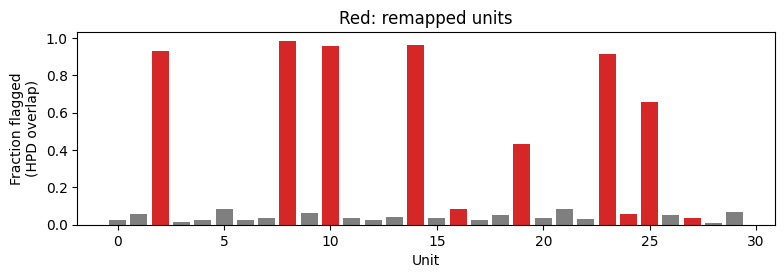

In [7]:
unit_flag_rate = np.array(
    [flags.hpd_overlap[after & (spike_unit == u)].mean() for u in range(n_units)]
)
most_flagged = np.argsort(unit_flag_rate)[::-1][: remapped.size]
overlap = np.intersect1d(most_flagged, remapped).size
print(
    f"{overlap} of the {remapped.size} most-flagged units after remapping are ones that remapped"
)

fig, ax = plt.subplots(figsize=(9, 2.5))
colors = np.where(np.isin(np.arange(n_units), remapped), "tab:red", "tab:gray")
ax.bar(np.arange(n_units), unit_flag_rate, color=colors)
ax.set(xlabel="Unit", ylabel="Fraction flagged\n(HPD overlap)", title="Red: remapped units")
plt.show()

## 6. Does a revised model fix it?

A revised decoder uses place fields re-estimated after the remapping (here, the true
ones). Evaluating both models on the same spikes, the paper counts the spikes flagged
under the original model but not the revised one: the misfit the revision explains.

In [8]:
revised_predictive = decode(fields_after)
revised_predictive[:remap_time] = predictive[:remap_time]
revised = ssc.event_diagnostics(
    revised_predictive, fields_after, spike_time_ind[after], spike_unit[after]
)
revised_flags = ssc.flag_events(revised, **thresholds)

original_flagged = flags.hpd_overlap[after]
rescued = original_flagged & ~revised_flags.hpd_overlap
newly_flagged = ~original_flagged & revised_flags.hpd_overlap
print(f"flagged by the original model: {original_flagged.sum()}")
print(
    f"  no longer flagged when revised: {rescued.sum()} ({rescued.sum() / original_flagged.sum():.0%})"
)
print(f"newly flagged by the revised model: {newly_flagged.sum()}")

flagged by the original model: 733
  no longer flagged when revised: 643 (88%)
newly flagged by the revised model: 15


(The revised decoder here starts from the original one's predictions at the
remapping; in practice one would refit the whole model.)

## A note on KL divergence

KL divergence grows whenever the prediction is broad relative to a spike's
likelihood, even if the spike falls well inside the prediction. The paper therefore
uses HPD overlap and the predictive p-value as the primary diagnostics and KL
divergence as a reference. See
[Interpreting the diagnostics](../../interpretation/) for more.

## Next steps

- [Using statespacecheck with your decoder](../../decoders/): getting these inputs
  from a real decoder.
- The API reference for `event_diagnostics`, `baseline_threshold` and `flag_events`.